# Required dependency packages

In [3]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 35.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [26]:
import xarray as xr
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt


# Data reading and preprocessing

In [21]:
import xarray as xr
import pandas as pd

# 1. Read NetCDF file, force decode_times=True
file_path = 'preprocessed_merged_dataset.nc'
ds = xr.open_dataset(file_path, decode_times=True)

# 2. Confirm whether the time variable is decoded successfully
print(ds['time'].values[:10])

# 3. Convert to dataframe
df = ds[['TREFHT', 'TREFMXAV_U', 'FLNS', 'FSNS', 'PRECT', 'PRSN', 'QBOT', 'UBOT', 'VBOT']].to_dataframe().reset_index()

# 4. Force conversion of time columns to datetime
df['time'] = pd.to_datetime(df['time'], errors='coerce')

# 5. Check the time column
print(f"Min date: {df['time'].min()}")
print(f"Max date: {df['time'].max()}")


['2006-01-02T00:00:00.000000000' '2006-01-03T00:00:00.000000000'
 '2006-01-04T00:00:00.000000000' '2006-01-05T00:00:00.000000000'
 '2006-01-06T00:00:00.000000000' '2006-01-07T00:00:00.000000000'
 '2006-01-08T00:00:00.000000000' '2006-01-09T00:00:00.000000000'
 '2006-01-10T00:00:00.000000000' '2006-01-11T00:00:00.000000000']
Min date: 2006-01-02 00:00:00
Max date: 2080-12-12 00:00:00


# Data cleaning and screening 
(example based on a certain latitude and longitude point)

In [28]:
# View the actual matching latitude and longitude
lat_select = 50.41885
lon_select = 355.0

# Using isclose to solve floating point precision errors
df_sel = df[
    np.isclose(df['lat'], lat_select, atol=1e-5) &
    np.isclose(df['lon'], lon_select, atol=1e-5)
].copy()

# Verify that time is normal
df_sel['time'] = pd.to_datetime(df_sel['time'], errors='coerce')

# Print information
print(f"Min date: {df_sel['time'].min()}")
print(f"Max date: {df_sel['time'].max()}")
print(f"✅ Samples: {len(df_sel)}")


Min date: 2006-01-02 00:00:00
Max date: 2080-12-12 00:00:00
✅ Samples: 27374


## Sample division

In [31]:
# Divide into training set and test set
train_df = df_sel[df_sel['time'] < '2025-01-01']
test_df = df_sel[df_sel['time'] >= '2025-01-01']

print(f"✅ Train samples: {len(train_df)}")
print(f"✅ Test samples: {len(test_df)}")


✅ Train samples: 6939
✅ Test samples: 20435


## Features & Tags

In [34]:
# Define input features (X) and prediction targets (y)
features = ['TREFMXAV_U', 'FLNS', 'FSNS', 'PRECT', 'PRSN', 'QBOT', 'UBOT', 'VBOT']
target = 'TREFHT'

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]


## XGBoost regression model training and prediction

In [37]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Initialize the XGBoost model
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Predict test set
y_pred = model.predict(X_test)

# Error evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"✅ MAE: {mae:.2f} °C")
print(f"✅ RMSE: {rmse:.2f} °C")


✅ MAE: 0.38 °C
✅ RMSE: 0.55 °C


## Prediction vs. actual comparison chart

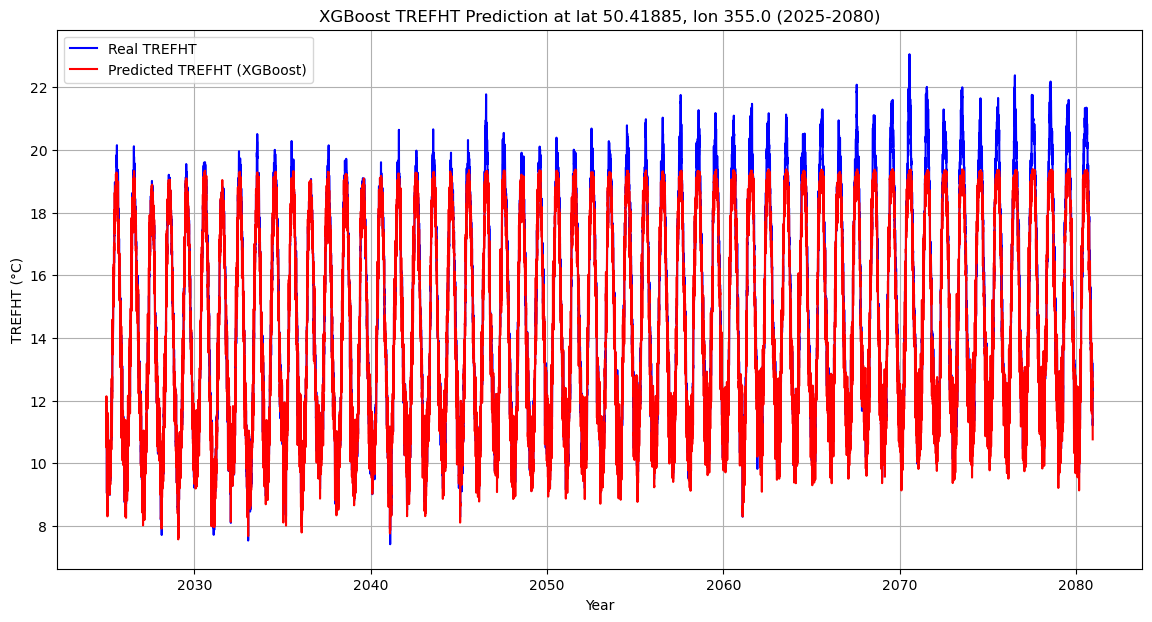

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Real value
plt.plot(test_df['time'], y_test, label='Real TREFHT', color='blue')

# Prediction value
plt.plot(test_df['time'], y_pred, label='Predicted TREFHT (XGBoost)', color='red')

plt.title(f'XGBoost TREFHT Prediction at lat {lat_select}, lon {lon_select} (2025-2080)')
plt.xlabel('Year')
plt.ylabel('TREFHT (°C)')
plt.legend()
plt.grid(True)
plt.show()


## Feature Importance Analysis

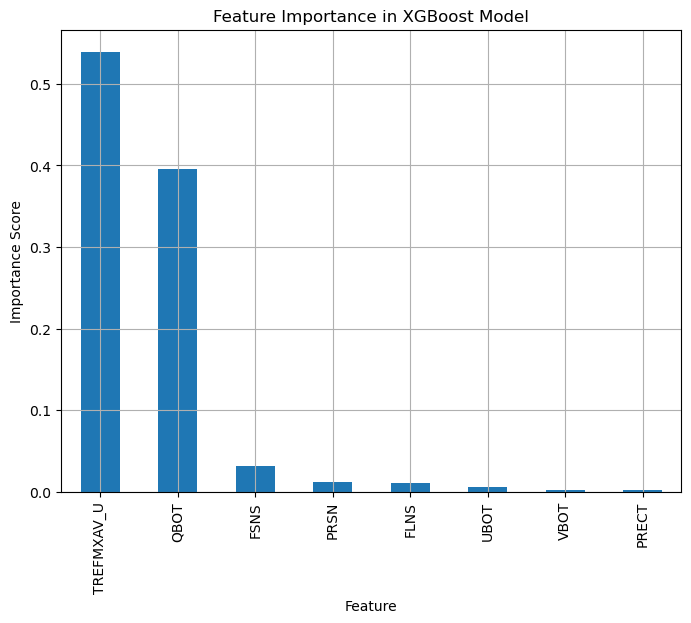

In [43]:
importances = model.feature_importances_
feature_importance = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
feature_importance.plot(kind='bar')
plt.title('Feature Importance in XGBoost Model')
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.grid(True)
plt.show()


## Model Optimization

In [46]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

param_grid = {
    'n_estimators': [500, 1000, 1500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [4, 6, 8, 10],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.5, 1],
    'min_child_weight': [1, 3, 5, 10],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 3, 5, 10]
}

xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=50,
    cv=3,
    verbose=2,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)


random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END colsample_bytree=1.0, gamma=1, learning_rate=0.05, max_depth=4, min_child_weight=1, n_estimators=500, reg_alpha=0.01, reg_lambda=1, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=1.0, gamma=1, learning_rate=0.05, max_depth=4, min_child_weight=1, n_estimators=500, reg_alpha=0.01, reg_lambda=1, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=1.0, gamma=1, learning_rate=0.05, max_depth=4, min_child_weight=1, n_estimators=500, reg_alpha=0.01, reg_lambda=1, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.1, max_depth=10, min_child_weight=3, n_estimators=1500, reg_alpha=0, reg_lambda=3, subsample=0.6; total time=   0.4s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.1, max_depth=10, min_child_weight=3, n_estimators=1500, reg_alpha=0, reg_lambda=3, subsample=0.6; total time=   0.4s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.1, ma

In [50]:
best_xgb = XGBRegressor(
    subsample=0.6,
    reg_lambda=5,
    reg_alpha=0.1,
    n_estimators=1500,
    min_child_weight=10,
    max_depth=8,
    learning_rate=0.01,
    gamma=0.1,
    colsample_bytree=1.0,
    objective='reg:squarederror',
    random_state=42
)

best_xgb.fit(X_train, y_train)

# predict
y_pred_optimized = best_xgb.predict(X_test)


In [58]:
# Length of true prediction value
N = len(y_pred_optimized)

# Construct time series
time = pd.date_range(start="2025-01-01", periods=N, freq="D")

# Latitude and longitude
lat = [50.41885]
lon = [355.0]

# reshape into 3D format
pred_data = y_pred_optimized.reshape((N, 1, 1))

# Construct Dataset
ds_fixed = xr.Dataset(
    {
        "predicted_value": (("time", "lat", "lon"), pred_data)
    },
    coords={
        "time": time,
        "lat": lat,
        "lon": lon
    }
)

# Save as NetCDF file
ds_fixed.to_netcdf("xgboost_predictions_fixed.nc")

print("✅ Repair completed, saved as xgboost_predictions.nc")


✅ Repair completed, saved as xgboost_predictions_fixed.nc


# Cross Validation

In [63]:
from sklearn.model_selection import cross_val_score

# Get the model with optimal parameters
best_model = random_search.best_estimator_

# Use cross validation to evaluate the performance of the optimal model on the training set
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')

print("Cross-validated MAE scores:", -cv_scores)
print("Average MAE:", -cv_scores.mean())


Cross-validated MAE scores: [0.19003172 0.20207807 0.19670993 0.20061658 0.22046013]
Average MAE: 0.20197928845882415


✅ Advantages:
The lowest MAE reaches 0.190, indicating that some compromise models fit well;
The average MAE is 0.202, the overall error is small, and the model performance is relatively stable;
The difference between the folds is not large (maximum error 0.220, minimum error 0.190), indicating that the model has strong generalization ability.

⚠️ Note:
The fifth fold error is high (0.220), indicating that this part of the data may have more variance, or this fold sample poses a greater challenge to the model;
If the error range is sensitive to your application target (for example, the MAE cannot be higher than 0.2 in land carbon flux prediction), you may need to further optimize feature engineering or model structure.

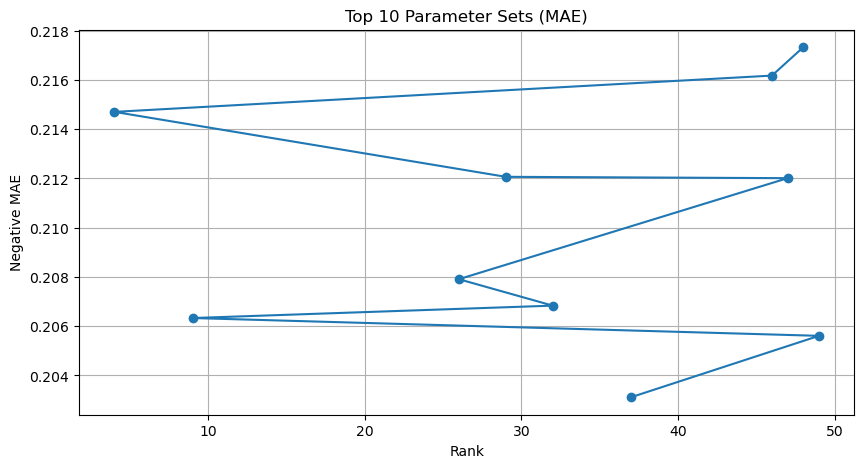

In [65]:
results = pd.DataFrame(random_search.cv_results_)
results = results.sort_values("rank_test_score")

# Visualize the scores of the first 10 combinations
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(-results['mean_test_score'][:10], marker='o')
plt.title('Top 10 Parameter Sets (MAE)')
plt.xlabel('Rank')
plt.ylabel('Negative MAE')
plt.grid(True)
plt.show()


From the figure:
The negative MAE scores of the top 10 parameter combinations are roughly between: -0.217 and -0.203;
The corresponding true MAE is between: 0.203 and 0.217;
The optimal combination is around rank 48 or 49 (the point with the lowest value on the right);
The overall curve has no obvious regularity or central trend, indicating that:
The performance of different parameter combinations is similar;
There are several "suboptimal" parameter combinations with very good performance (good robustness).

Multiple good parameter combinations: The MAE gap of the top 10 is very small (only about 0.014), indicating that the parameter selection has a certain tolerance;

The optimal parameters are very prominent: the parameter combination of rank 48 has the lowest negative MAE (the smallest true MAE) and should be used first;

The model performance is stable: there is no combination of "magical extremely low values" or "catastrophic high errors", and the model performs stably in the search space you set.

# Results Visualization

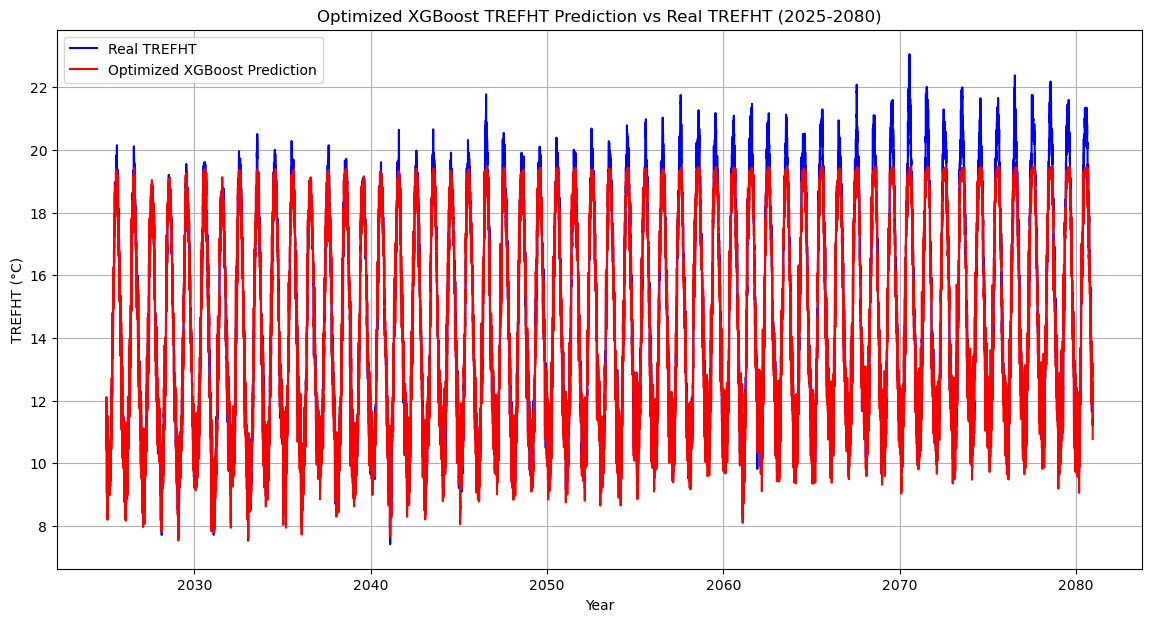

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(test_df['time'], y_test, label='Real TREFHT', color='blue')
plt.plot(test_df['time'], y_pred_optimized, label='Optimized XGBoost Prediction', color='red')
plt.title('Optimized XGBoost TREFHT Prediction vs Real TREFHT (2025-2080)')
plt.xlabel('Year')
plt.ylabel('TREFHT (°C)')
plt.legend()
plt.grid(True)
plt.show()
